# 05 — Figures for the manuscript

Generates the figures Reviewer 1 explicitly asked for:

1. Cumulative-return curves per stock during the 2024 test period.
2. Drawdown curves per stock.
3. Win-Rate × Sharpe scatter (§2.8 of the revision plan).
4. Horizon vs. {# trades, Sharpe, Win-Rate} line plot.

In [5]:
import sys, json, pathlib
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == 'notebooks' else pathlib.Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src import config as cfg_mod

cfg = cfg_mod.load_config()
# Expected: `results/raw/*.csv` includes a `Test_TradeReturns` column (JSON-encoded list).
# hpo_traditional.evaluate_cell already produces this in `__test_trade_returns__` --
# add a small post-processing step in your driver to persist it as a column.

In [6]:
# (1) + (2) cumulative return + drawdown per stock.
#
# This block assumes results/per_stock_test_trades.csv with columns
#   Stock, Date, TradeReturn (chronological)
# produced by a small dump script after the controlled-table run.
try:
    td = pd.read_csv(ROOT / 'results' / 'per_stock_test_trades.csv', parse_dates=['Date'])
except FileNotFoundError:
    print('Trade-level test returns not yet dumped — run the controlled cell with --dump-trades.')
    td = None
if td is not None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for s, sub in td.groupby('Stock'):
        sub = sub.sort_values('Date')
        equity = (1 + sub['TradeReturn']).cumprod()
        peak = equity.cummax()
        dd = (equity - peak) / peak
        axes[0].plot(sub['Date'], equity, label=s)
        axes[1].plot(sub['Date'], dd, label=s)
    axes[0].set_title('Cumulative return (2024 test)')
    axes[1].set_title('Drawdown (2024 test)')
    for ax in axes: ax.legend(); ax.grid(alpha=0.3)
    fig.tight_layout(); fig.savefig('../results/fig_equity_drawdown.pdf'); plt.show()

Trade-level test returns not yet dumped — run the controlled cell with --dump-trades.


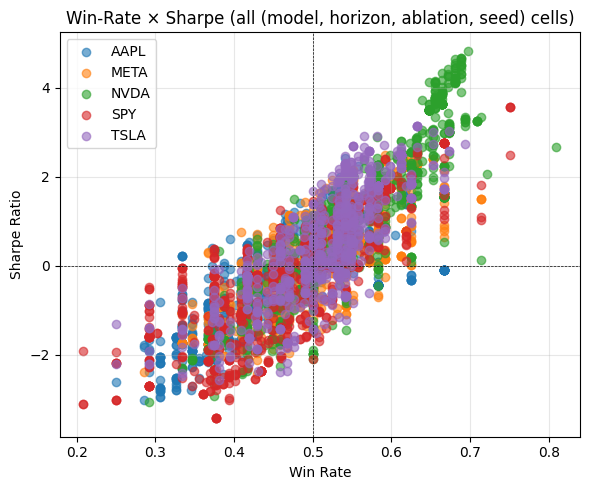

In [7]:
# (3) Win-Rate × Sharpe scatter
RAW = cfg_mod.results_dir() / 'raw'
df = pd.concat([pd.read_csv(p) for p in sorted(RAW.glob('*.csv'))], ignore_index=True)
fig, ax = plt.subplots(figsize=(6, 5))
for s, sub in df.groupby('Stock'):
    ax.scatter(sub['Test_WinRate'], sub['Test_Sharpe'], label=s, alpha=0.6)
ax.axhline(0, ls='--', color='k', lw=0.5); ax.axvline(0.5, ls='--', color='k', lw=0.5)
ax.set_xlabel('Win Rate'); ax.set_ylabel('Sharpe Ratio')
ax.set_title('Win-Rate × Sharpe (all (model, horizon, ablation, seed) cells)')
ax.legend(); ax.grid(alpha=0.3); fig.tight_layout()
fig.savefig('../results/fig_winrate_sharpe.pdf'); plt.show()

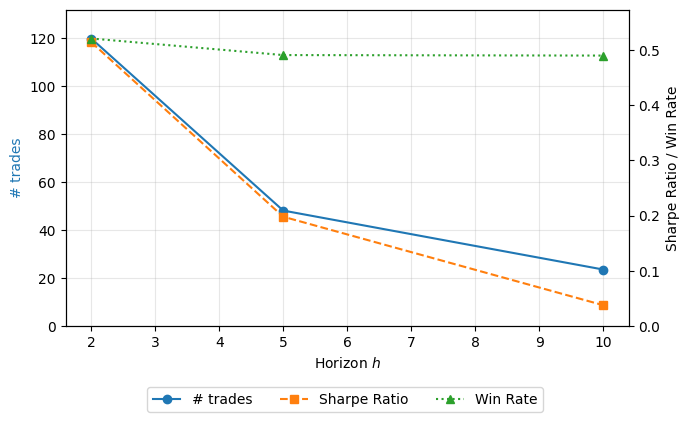

In [10]:
# (4) Horizon vs. {# trades, Sharpe, Win-Rate}
by_h = df.groupby('Horizon').agg(Trades=('Test_Trades', 'mean'),
                                  Sharpe=('Test_Sharpe', 'mean'),
                                  WinRate=('Test_WinRate', 'mean')).reset_index()
fig, ax1 = plt.subplots(figsize=(7, 4.2))
ax2 = ax1.twinx()
l1, = ax1.plot(by_h['Horizon'], by_h['Trades'], 'o-', label='# trades', color='C0')
l2, = ax2.plot(by_h['Horizon'], by_h['Sharpe'], 's--', label='Sharpe Ratio', color='C1')
l3, = ax2.plot(by_h['Horizon'], by_h['WinRate'], '^:', label='Win Rate', color='C2')
ax1.set_xlabel('Horizon $h$'); ax1.set_ylabel('# trades', color='C0')
ax2.set_ylabel('Sharpe Ratio / Win Rate')
# headroom so the lines never touch the frame or the legend
ax1.set_ylim(0, by_h['Trades'].max() * 1.1)
ax2.set_ylim(min(0.0, by_h['Sharpe'].min()),
             max(by_h['Sharpe'].max(), by_h['WinRate'].max()) * 1.1)
ax1.grid(alpha=0.3)
# single combined legend BELOW the axes -- never overlaps the data
fig.legend([l1, l2, l3], ['# trades', 'Sharpe Ratio', 'Win Rate'],
           loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.01), frameon=True)
fig.tight_layout(rect=[0, 0.07, 1, 1])
fig.savefig('../results/fig_horizon_tradeoffs.pdf', bbox_inches='tight')
plt.show()